
# <span style="color:rgb(213,80,0)">Primer examen parcial. Robótica.</span>

Miranda Meza Roberto


Grupo 01

## Introducción

El presente documento tiene la intención de explicar todo el modelado cinemático y dinámico general de un robot Scara. Este tipo de robots se conocen también como RRR porque en esencia se componen de tres eslabones unidos por juntas rotacionales, las juntas rotacionales se identifican por una R.


A lo largo del documento se explica paso por paso el modelado del robot y se incluyen algunos esquemas que permiten entender geométricamente qué están expresando las ecuaciones descritas en el código y los resultados obtenidos.


La primer parte del trabajo muestra el modelado cinemático dividido de manera general en tres; de la postura, de las velocidades y de las aceleraciones. El modelado de la postura sirve para conocer la posición del robot en todo momento de acuerdo con la tarea que se le encargue, siempre que se define un sistema de referencia Base o también llamado Inercial, el robot se mueve con posiciones relativas a este sistema. Este sistema Inercial no es nada más que el espacio de trabajo donde va a colocarse el robot y el origen del sistema está definido en un punto de interés en ese espacio de trabajo. Por otro lado, está el modelado de las velocidades, el cual sirve para conocer y predecir el movimiento de los eslabones que componen al robot, ya que cada uno se moverá a velocidades diferentes dependiendo de la trayectoria (tarea) que se le encargue al robot y que está descrita por el punto P del eslabón tres. Y finalmente está el modelo de las aceleraciones, este modelo tiene mayor interés en el cálculo de la dinámica del robot, esto es, que cada uno de los eslabones requerirá un cierto par para poder moverse y que la tarea sea realizada. Este par es aplicado desde las juntas donde se encontrarán los motores que lo aplican, por lo tanto, el modelado dinámico nos permite **por lo menos** en este documento darnos una idea del par como especificación, que deben tener los motores que se utilicen. Y ¿por qué 'por lo menos'? porque el par encontrado a partir del modelado dinámico no considera ni el rozamiento de las juntas ni las cargas externas aplicadas al robot.


Finalmente se encuentra un apartado sobre las conclusiones del trabajo con base en los resultados simbólicos obtenidos y lo que se interpreta del modelado dinámico inverso y directo del robot Scara.

## Definición de funciones

A continuación se definie la matriz de transformación general que permite transformar las coordenadas de un sistema a otro, considerando los tres giros (roll, pitch y yaw) y los desplazamientos en las tres direcciones principales ( $i\;,j,k$ )


In [1]:
%Deficición de la función de manera simbolica
syms Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j)

%Definición de la transformación homógenea general
Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) = [cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j) x_i_j; sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j) y_i_j; -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j) z_i_j; 0 0 0 1]

## Modelado del robot Scara

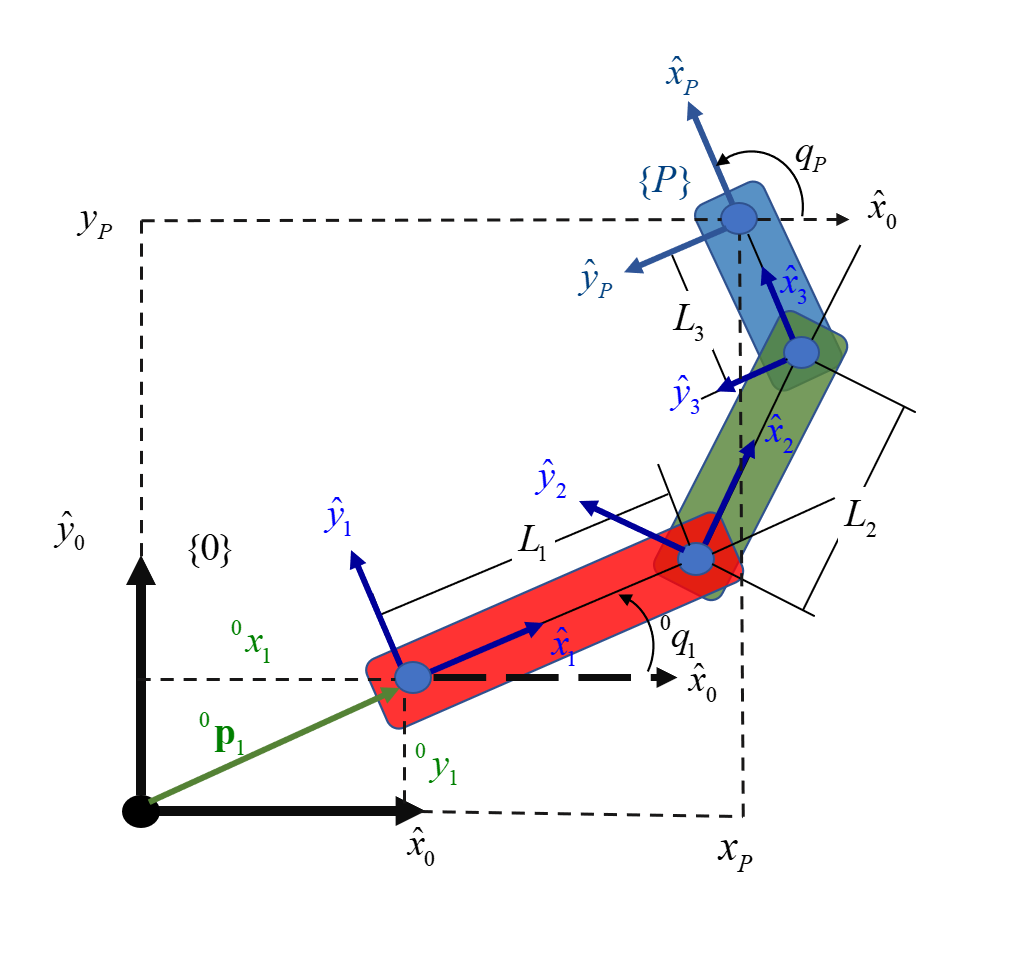

### Planteamiento del modelo cinemático de la posición

En este apartado se plantean las matrices de transformación de cada uno de los sistemas de referencia o marcos generados para hacer la descripción de la estructura del robot con respecto al marco de referencia inercial.


La primer matriz representada es la matriz de transformación del marco de referencia (1) al marco de referencia inercial. Considerando el ángulo de giro ${}^0{\theta }_1$ y los desplazamientos señalados por el vector de posición ${}^0p_1$. Este ángulo de giro es tal que nos permite señalar uno de los vectores unitarios


( ${\overset{\wedge }{x} }_1 ,{\overset{\wedge }{y} }_1$ )  en dirección a la próxima junta. Esto es por facilidad para no tener componentes de 'x' o de 'y' en el desplazamiento y que solo se represente en una componente.


In [2]:
syms x_O_1 y_O_1 theta_O_1 L_2 theta_1_2 L_3 theta_2_3 L_1

T_O_1 = Tij(x_O_1,y_O_1,0,0,0,theta_O_1)


Esta es la matriz de transformación del marco de referencia (1) al (2). Otra recomendación fue que la rotación sea en sentido antihorario para también evitar los cambios de signo por el giro en sentido horario que es negativo. De este modo el giro en ( ${\overset{\wedge }{z} }_1$ ) en sentido antihorario y el desplazamiento deja a ( ${\overset{\wedge }{x} }_1$ ) señalando hacia la dirección de la junta 3, conviertiéndo al sistema en ( ${\overset{\wedge }{x} }_2 ,{\overset{\wedge }{y} }_2$ ) .


In [3]:
T_1_2 = Tij(L_1,0,0,0,0,theta_1_2)


La transformación del marco de referencia 2 a 3 es un desplazamiento de la junta 2 a la junta 3 en la dirección de ( ${\overset{\wedge }{x} }_2$ ) y un giro en ( ${\overset{\wedge }{z} }_2$ ).


In [4]:
T_2_3 = Tij(L_2,0,0,0,0,theta_2_3)


Finalmente la transformación del marco de referencia 3 al marco de referencia P es solo un desplazamiento en la dirección de ( ${\overset{\wedge }{x} }_3$ ), por lo que al no haber giro, la matriz de rotación se representa como la matriz identidad.


In [5]:
T_3_P = Tij(L_3,0,0,0,0,0)


Recordando que los marcos de referencia sirven para representar puntos en el espacio (su origen). Con la información anterior ya se puede hacer una transformación que lleve del marco de referencia inercial al marco de referencia del punto P, con un vector ( ${}^0P_P$ ) que representa el desplazamiento del punto P y un vector ( ${}^0{\theta }_P$ ) que representa la orientación de su marco de referencia. Generando lo que a continuación se le conoce como el vector de postura.


In [6]:
T_O_P = simplify(T_O_1*T_1_2*T_2_3*T_3_P)

### Vector de postura del robot

El vector de postura almacena la información del lugar geométrico generado por el punto P que se encuentra al final del tercer eslabón y ángulos o variables independientes.


In [7]:
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]

### Modelo cinemático directo de las velocidades

Este modelo se puede resolver cuando se conocen los valores de los ángulos ( ${}^0{\theta }_1$, ${}^1{\theta }_2$, ${}^2{\theta }_3$ ) que son las variables del sistema que conforman al vector de variables independientes ( $q$ ).


El modelo parte de la derivada total del vector de postura: $\frac{\mathrm{d}}{\mathrm{d}t}{}^o{\xi }_P=\frac{\mathrm{d}}{\mathrm{d}t}{}^o{\xi }_P\left(q\right)$


In [8]:
syms J_theta J_theta_inv xi_O_P_Punto q_Punto theta_dot_0_1 theta_dot_1_2 theta_dot_2_3 q_dot
q = transpose([theta_O_1;theta_1_2;theta_2_3])

In [9]:
q_Punto = transpose([theta_dot_0_1;theta_dot_1_2;theta_dot_2_3])

In [10]:
xi_O_P_Punto = J_theta * (q_dot)

In [11]:
J_theta = jacobian(xi_O_P,[theta_O_1,theta_1_2,theta_2_3])

### Modelo cinemático inverso de las velocidades

El modelo cinemático inverso parte de conocer cómo se va a mover el punto P para conocer el movimiento de las juntas del robot. Por lo que en ese caso la incógnita es la derivada del vector de variables independientes ( $\dot{q}$ ). Se plantea la siguiente ecuación matricial:


$$\dot{q} =J_{\theta }^{-1} \left(q\right){}^o{\dot{\xi} }_P$$

Donde $J_{\theta }^{-1} \left(q\right)$ la matriz Jacobiana inversa es:


In [12]:
J_theta_inv = inv(J_theta)

### Modelo cinemático de las aceleaciones

Este modelo se divide en dos al igual que el modelo cinemático de las velocidades, directo e inverso. Su utilidad se presenta en la solución dinámica del robot. Ambos modelos parten de la derivada total del vector ${}^O{\dot{\xi} }_P$ generando la siguiente ecuación:


$$\frac{\mathrm{d}}{\mathrm{d}t}{}^O{\dot{\xi} }_P=\frac{\mathrm{d}}{\mathrm{d}t}\left(J_{\theta } \left(q\right)\dot{\;q} \right)$$
####         Modelo cinemático directo de las aceleraciones

Se ocupa cuando se conocen los valores de las aceleraciones de las variables independientes $\left(\ddot{q} \right)$. Se tiene entonces que la aceleración total del punto P con respecto al origen del sistema inercial es:


$${}^O{\ddot{\xi} }_P=J_{\theta } \left(q\right)\;\ddot{q} +\dot{q} \;{\dot{J} }_{\theta } \left(q\right)$$

Donde ${\dot{J} }_{\theta } \left(q\right)$ , $\ddot{q}$ y ${}^O{\ddot{\xi} }_P$ son:


In [13]:
syms xi_ddot_O_P J_dot_theta q_ddot q_ddot_modeloInverso theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3

J_dot_theta = diff(J_theta,theta_O_1) + diff(J_theta,theta_1_2) + diff(J_theta,theta_2_3)

In [14]:
q_ddot = transpose([theta_ddot_0_1;theta_ddot_1_2;theta_ddot_2_3])

In [15]:
xi_ddot_O_P = J_theta * transpose(q_ddot) + J_dot_theta * transpose(q_Punto)

####         Modelo cinemático inverso de las aceleraciones

A partir del movimiento o tarea que realizará el robot se tiene definida una trayectoria, por lo que se pueden conocer los valores de aceleración que tendrá el punto P respecto al sistema inercial en esa trayectoria. Lo que prosigue es encontrar los valores de las aceleraciones de las variables independientes $\left(\ddot{q} \right)$.


$$\ddot{q} =J_{\theta }^{-1} \left(q\right)\left({}^O{\ddot{\xi} }_P-\dot{q} \;{\dot{J} }_{\theta } \left(q\right)\right)$$

Donde $\ddot{q}$ es:


In [16]:
q_ddot_modeloInverso = J_theta_inv * xi_ddot_O_P - transpose(q_Punto*J_dot_theta)

## Modelo dinámico por ecuaciones de Eüler\-Lagrange

Para el cálculo dinámico se deben considerar los centros de masa de cada uno de los eslabones que es el punto donde se representan las fuerzas que actúan sobre ellos.


El modelo dinámico por ecuaciones de Eüler\-Lagrange requiere de obtener el Lagrangeano. De manera general para el sistema se representó así:


$$\Gamma \left(q,\dot{q} \right)=\left(k_1 +k_2 +k_3 \right)-\left(u_1 +u_2 +u_3 \right)$$

En otras palabras, la energía en los eslabones no se está conservando, por lo que entre su energía cinética y su energía potencial debe haber algo que provoque el movimiento.


Las ecuaciones de Eüler \- Lagrange son las que describen la dinámica del sistema.


$$\tau_i =\frac{\mathrm{d}}{\mathrm{d}t}\left(\frac{\partial }{\partial \dot{q_i } }\Gamma \right)-\frac{\partial }{\partial q_i }\Gamma$$
####     Cálculo de la energía cinética y potencial

Se emplearan las siguientes ecuaciones para el cálculo de la energía cinética y potencial:


 $k_i =\frac{m_i }{2}{\mathbf{v}}_{C_i }^T {\mathbf{v}}_{C_i } +\frac{1}{2}{\mathbf{\omega }}_{C_i }^T {\mathbf{I}}_{C_i } {\mathbf{\omega }}_{C_i }$   ;   $u_i =-m_i \;{\mathit{\mathbf{g}}}^T \;{}^OP_{\textrm{Ci}}$


Para cada uno de los eslabones del robot se deben calcular las velocidades de sus centros de masa. Las velocidades angulares de sus centros de masa son iguales a las de cualquier parte del eslabón.


Se deben calcular los vectores de posición ${}^OP_{\textrm{Ci}}$ y los valores de las matrices de inercia en los centros de masa ${}I_{\textrm{Ci}}$. El vector de la aceleración gravitaroria se consideró como en la imagen siguiente:


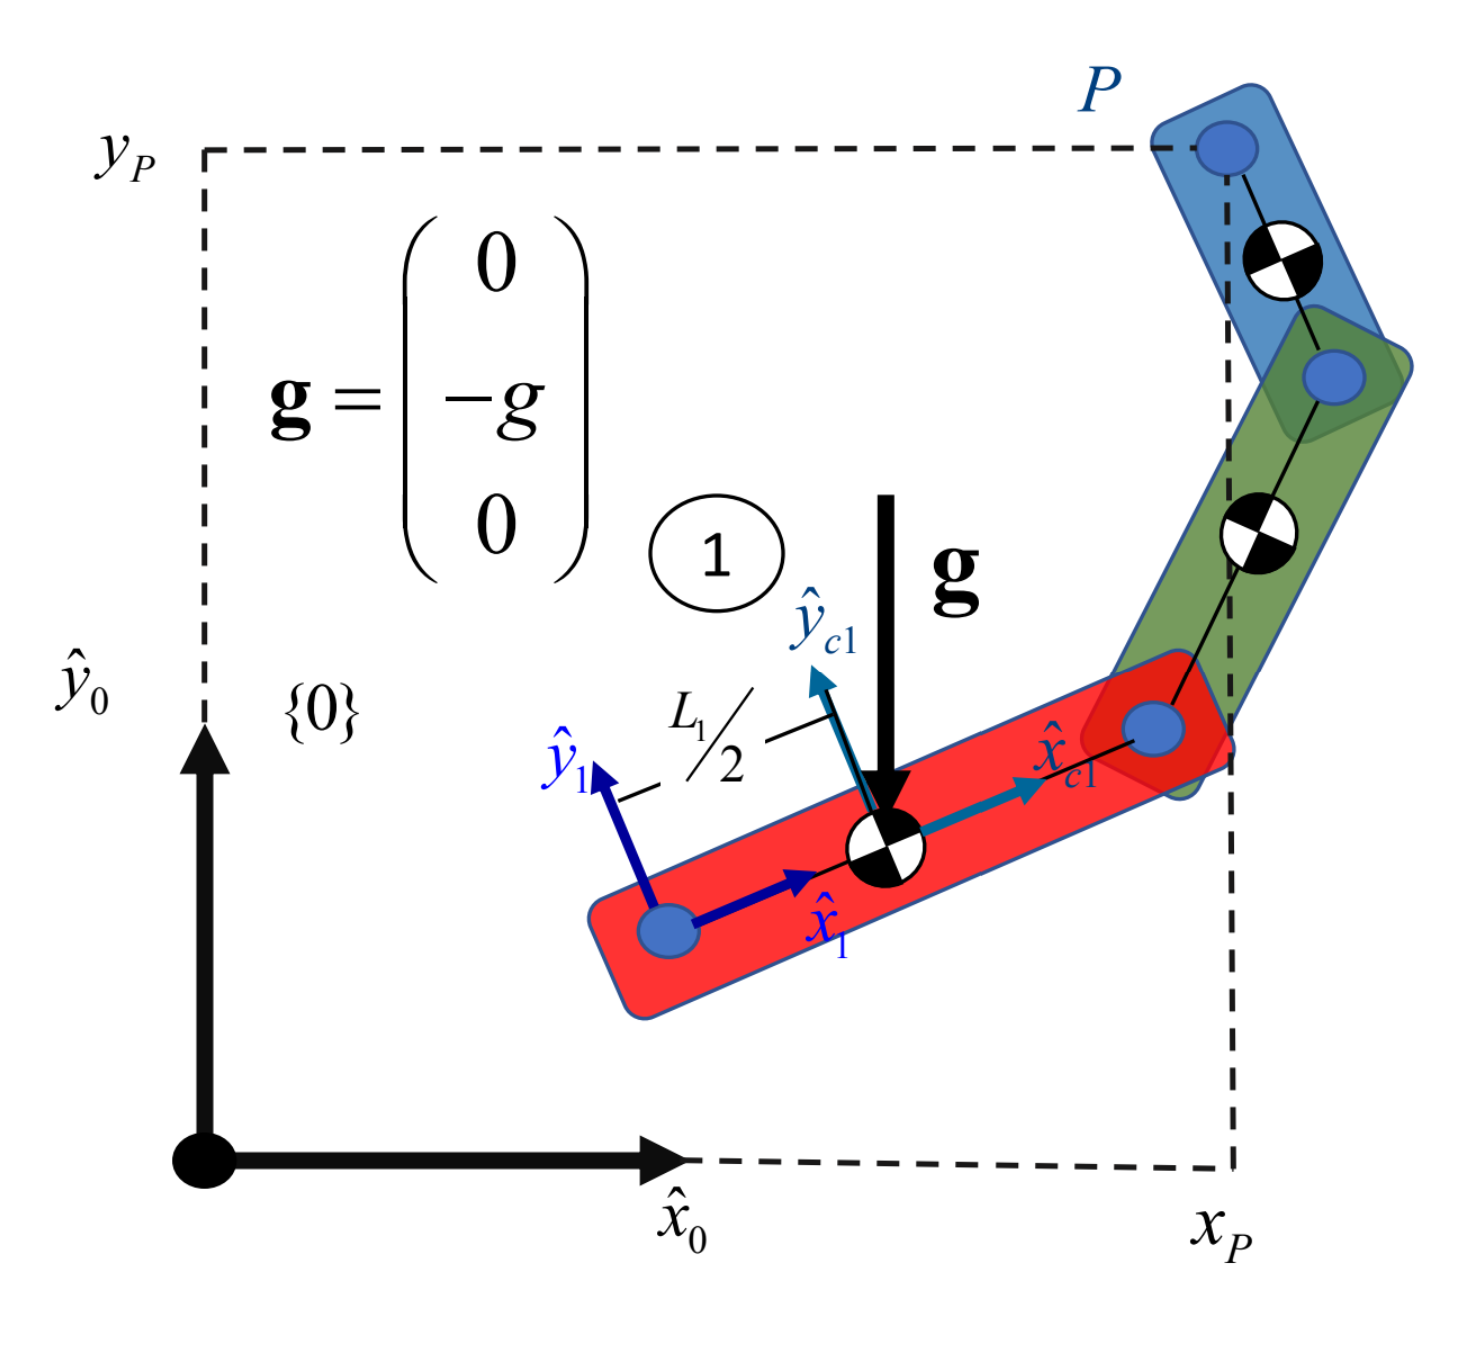

### Cálculo de la posición de los centros de masa

A continuación se muestra el cálculo de la posición de los centros de masa:

####         <u>Para el eslabón 1</u>

Se realiza la transformación del marco de referencia en el centro de masa al marco de referencia {1} donde está la primer junta.


In [17]:
syms x_1_C1 x_2_C2 x_3_C3

T_1_C1 = Tij(x_1_C1,0,0,0,0,0)


Después se realiza la transformación del marco de referencia del centro de masa al inercial.


In [18]:
T_O_C1 = T_O_1*T_1_C1

####          <u>Para el eslabón 2</u>

Se realiza la transformación del marco de referencia en el centro de masa al marco de referencia {2} donde está la segunda junta.


In [19]:
T_2_C2 = Tij(x_2_C2,0,0,0,0,0)


Después se realiza la transformación del marco de referencia del centro de masa al inercial.


In [20]:
T_O_C2 = T_O_1*T_1_2*T_2_C2

####          <u>Para el eslabón 3</u>

Se realiza la transformación del marco de referencia en el centro de masa al marco de referencia {3} donde está la tercer junta.


In [21]:
T_3_C3 = Tij(x_3_C3,0,0,0,0,0)


Después se realiza la transformación del marco de referencia del centro de masa al inercial.


In [22]:
T_O_C3 = T_O_1*T_1_2*T_2_3*T_3_C3


**De las matrices de transformación anteriores se obtienen vectores de posición de los centros de masa con respecto al sistema inercial**


$${}^OP_{\textrm{Ci}}$$

Se toman únicamente los elementos de las filas 1, 2 y 3 de la última columna, pues representan las posiciones en **x**, **y** y **z**


In [23]:
p_O_C1 = [T_O_C1(1,4);T_O_C1(2,4);T_O_C1(3,4)]

In [24]:
p_O_C2 = simplify([T_O_C2(1,4);T_O_C2(2,4);T_O_C2(3,4)])

In [25]:
p_O_C3 = simplify([T_O_C3(1,4);T_O_C3(2,4);T_O_C3(3,4)])

### Cálculo de las velocidades de los centros de masa

De un modo muy parecido a cómo se calculó el modelo cinemático del punto P con respecto al sistema inercial dandonos el vector:


$${}^O{\xi }_P$$

También se realiza lo mismo pero para cada uno de los centros de masa y luego se deriva el vector $\xi$ por lo tanto:


$${}^O{\mathit{\mathbf{v}}}_{C\;i}=\left(\frac{\partial }{\partial {}^0{\theta }_1}{}^OP_{\textrm{Ci}}\;\;\;\;\;\;\frac{\partial }{\partial {}^1{\theta }_2}{}^OP_{\textrm{Ci}}\;\;\;\;\frac{\partial }{\partial {}^2{\theta }_3}{}^OP_{\textrm{Ci}}\right)\dot{\mathit{\mathbf{q}}}$$

In [26]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3

v_O_C1 = diff(p_O_C1,theta_O_1)*theta_dot_O_1+diff(p_O_C1,theta_1_2)*theta_dot_1_2+diff(p_O_C1,theta_2_3)*theta_dot_2_3

In [27]:
v_O_C2 = diff(p_O_C2,theta_O_1)*theta_dot_O_1+diff(p_O_C2,theta_1_2)*theta_dot_1_2+diff(p_O_C2,theta_2_3)*theta_dot_2_3

In [28]:
v_O_C3 = diff(p_O_C3,theta_O_1)*theta_dot_O_1+diff(p_O_C3,theta_1_2)*theta_dot_1_2+diff(p_O_C3,theta_2_3)*theta_dot_2_3

### Cálculo de la velocidades angulares

A partir de la ecuación de propagación de las velocidades angulares se pueden obtener para sustituirlas en la obtención del Lagrangeano:


$${}^{\mathit{\mathbf{i}}+1}{\omega }_{\mathit{\mathbf{i}}+1}={}^{i+1}{\mathit{\mathbf{R}}}_i\;{}^{\mathit{\mathbf{i}}}{\omega }_{\mathit{\mathbf{i}}}+{}^{\mathit{\mathbf{i}}+1}{\hat{\eta} }_{\mathit{\mathbf{i}}+1}\;{\dot{\theta} }_{i+1}$$


El vector $\hat{\eta}$ es el vector que indica la dirección de giro de los eslabones, en este caso al ser en el plano su valor es el del vector unitario $\hat{k}$. Mientras que $\mathit{\mathbf{R}}$ es la matriz de rotación que para todos los casos es la matriz de rotación en (**z**) pero como la propagación va de cada eslabón hacia atrás esto quiere decir que se necesita la matriz de rotación inversa que sería la matriz transpuesta en (**z**).

####        <u> Propagación para el eslabón 1</u>

In [29]:
syms omega_1_1 omega_2_2 omega_3_3
omega_1_1

In [30]:
omega_O_O = [0;0;0]

omega_O_O = 3x1
     0
     0
     0

In [31]:
n_1_1 = [0;0;1]

n_1_1 = 3x1
     0
     0
     1

In [32]:
R_O_1 = [T_O_1(1,1),T_O_1(1,2),T_O_1(1,3);T_O_1(2,1),T_O_1(2,2),T_O_1(2,3);T_O_1(3,1),T_O_1(3,2),T_O_1(3,3)]

In [33]:
R_1_O = transpose(R_O_1)

####        <u> Ecuación de propagación para el eslabón 1</u>

In [34]:
omega_1_1 = R_1_O*omega_O_O+n_1_1*theta_dot_O_1

####        <u> Propagación para el eslabón 2</u>

In [35]:
omega_2_2

In [36]:
n_2_2 = [0;0;1]

n_2_2 = 3x1
     0
     0
     1

In [37]:
R_1_2 = [T_1_2(1,1),T_1_2(1,2),T_1_2(1,3);T_1_2(2,1),T_1_2(2,2),T_1_2(2,3);T_1_2(3,1),T_1_2(3,2),T_1_2(3,3)]

In [38]:
R_2_1 = transpose(R_1_2)

####        <u> Ecuación de propagación para el eslabón 2</u>

In [39]:
omega_2_2 = R_2_1*omega_1_1+n_2_2*theta_dot_1_2

####        <u> Propagación para el eslabón 3</u>

In [40]:
omega_3_3

In [41]:
n_3_3 = [0;0;1]

n_3_3 = 3x1
     0
     0
     1

In [42]:
R_2_3 = [T_2_3(1,1),T_2_3(1,2),T_2_3(1,3);T_2_3(2,1),T_2_3(2,2),T_2_3(2,3);T_2_3(3,1),T_2_3(3,2),T_2_3(3,3)]

In [43]:
R_3_2 = transpose(R_2_3)

####        <u> Ecuación de propagación para el eslabón 3</u>

In [44]:
omega_3_3 = R_3_2*omega_2_2+n_3_3*theta_dot_2_3

### Defición de los elementos de inercia

Las matrices de inercia son simétricas y si consideramos que los eslabones son elementos con área transversal constante y simétrica solo habrá valores en la diagonal principal.


In [45]:
syms g I_xx1 I_yy1 I_zz1 I_xx2 I_yy2 I_zz2 I_xx3 I_yy3 I_zz3
%vector de gravedad

g_v = [0;-g;0]


Matriz de los momentos de inercia del centro de masa del eslabón 1 con respecto a los tres ejes.


In [46]:
I_C1 = [I_xx1,0,0;0,I_yy1,0;0,0,I_zz1]


Matriz de los momentos de inercia del centro de masa del eslabón 2 con respecto a los tres ejes.


In [47]:
I_C2 = [I_xx2,0,0;0,I_yy2,0;0,0,I_zz2]


Matriz de los momentos de inercia del centro de masa del eslabón 3 con respecto a los tres ejes.


In [48]:
I_C3 = [I_xx3,0,0;0,I_yy3,0;0,0,I_zz3]

### Cáculo del Lagrangeano

Como se mencionó anteriormente, se requiere conocer el Lagrangeano para obtener las ecuaciones de Eüler \- Lagrange:


 $\Gamma \left(q,\dot{q} \right)=\left(k_1 +k_2 +k_3 \right)-\left(u_1 +u_2 +u_3 \right)$         **(1)**


 $k_i =\frac{m_i }{2}{\mathbf{v}}_{C_i }^T {\mathbf{v}}_{C_i } +\frac{1}{2}{\mathbf{\omega }}_{C_i }^T {\mathbf{I}}_{C_i } {\mathbf{\omega }}_{C_i }$                      **(2)**


 $u_i =-m_i \;{\mathit{\mathbf{g}}}^T \;{}^OP_{\textrm{Ci}}$                                     **(3)**


Se sustituye en la ecuación **(2)** los valores para calcular las energías cinéticas de cada uno de los eslabones del robot.

#### Energía cinética del eslabón 1

In [49]:
syms m_1 m_2 m_3
k_1 = simplify((m_1/2)*transpose(v_O_C1)*v_O_C1+(1/2)*transpose(omega_1_1)*I_C1*omega_1_1)

#### Energía cinética del eslabón 2

In [50]:
k_2 = simplify((m_2/2)*transpose(v_O_C2)*v_O_C2+(1/2)*transpose(omega_2_2)*I_C2*omega_2_2)

#### Energía cinética del eslabón 3

In [51]:
k_3 = simplify((m_3/2)*transpose(v_O_C3)*v_O_C3+(1/2)*transpose(omega_3_3)*I_C3*omega_3_3)


Se sustituye en la ecuación **(3)** los valores para calcular las energías cinéticas de cada uno de los eslabones del robot.

#### Energía potencial del eslabón 1

In [52]:
u_1 = -m_1*transpose(p_O_C1)*g_v

#### Energía potencial del eslabón 2

In [53]:
u_2 = -m_2*transpose(p_O_C2)*g_v

#### Energía potencial del eslabón 3

In [54]:
u_3 = -m_3*transpose(p_O_C3)*g_v

### Cálculo del Lagrangeano

Aplicando la ecuación **(3)** se obtiene el valor del Lagrangeano


In [55]:
La = (k_1+k_2+k_3)-(u_1+u_2+u_3)

## Cálculo de los pares

Con las ecuaciones de Eüler \- Lagrange se obtiene el par cinemático que cada una de las juntas debe aplicar para mover los eslabones de acuerdo con las características que ya se han proporcionado sobre ellos (masa, momento de inercia, longitudes) y las velocidades de giro que se van a aplicar.


Basados en la siguiente ecuación del elemento iesimo:


$$\tau_i =\frac{\mathrm{d}}{\mathrm{d}t}\left(\frac{\partial }{\partial \dot{q_i } }\Gamma \right)-\frac{\partial }{\partial q_i }\Gamma$$

El cálculo en Matlab se dividió de la siguiente forma:

1.  Se obtiene el valor del Lagrangeano $\Gamma$.
2. Se deriva el Lagrangeano con respecto a las velocidades de giros o desplazamientos, en este caso por el robot Scara solamente giros, a esta derivada se le dio el nombre de D\_theta(i)
3. Después se deriva totalmente D\_theta(i) por lo que se deriva con respecto a la posición por su velocidad más las derivadas respecto a su velocidad por su aceleración.

In [56]:
D_theta1 = diff(La,theta_dot_O_1)

#### Cálculo del par $\tau_1$ de la primer junta rotacional

In [57]:

tao_1 = diff(D_theta1,theta_O_1)*theta_dot_O_1 + diff(D_theta1,theta_1_2)*theta_dot_1_2 + diff(D_theta1,theta_2_3)*theta_dot_2_3 + diff(D_theta1,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta1,theta_dot_1_2)*theta_ddot_1_2+diff(D_theta1,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_O_1)

In [58]:
D_theta2 = diff(La,theta_dot_1_2)

#### Cálculo del par $\tau_2$ de la segunda junta rotacional

In [59]:
tao_2 = diff(D_theta2,theta_O_1)*theta_dot_O_1 + diff(D_theta2,theta_1_2)*theta_dot_1_2 + diff(D_theta2,theta_2_3)*theta_dot_2_3 + diff(D_theta2,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta2,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta2,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_1_2)

In [60]:
D_theta3 = diff(La,theta_dot_2_3)

#### Cálculo del par $\tau_3$ de la tercer junta rotacional

In [61]:
tao_3 = diff(D_theta3,theta_O_1)*theta_dot_O_1 + diff(D_theta3,theta_1_2)*theta_dot_1_2 + diff(D_theta3,theta_2_3)*theta_dot_2_3 + diff(D_theta3,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta3,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta3,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_2_3)

#### Vector de los pares $\tau_i$ en las juntas del robot

In [62]:
tao = [tao_1;tao_2;tao_3]

## Cálculo del vector de pares por inercia

El mismo vector de pares puede ser expresado a partir de varios fenómenos que afectan al robot, empezando por:

-  La inercia de los eslabones.
-  Los efectos de la aceleración de Coriolis, es una aceleración opuesta a la aceleración centrípeta que trata de desviar al cuerpo de su trayectoria al girar.
-  Los efectos de la gravedad.
-  La fricción en las juntas.
-  Y lo más importante, las fuerzas externas debidas a las tareas del robot.

En este caso nos quedamos con las primeras tres. A continuación se obtienen las matrices de inercia:


Se sustityen todas las variables por cero **menos** la aceleración angular del ángulo ${}^O{\theta }_1$ que se sutituyó por 1, dejando a un vector que representa el par deido a la inercia del eslabón 1.


In [63]:
M1 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[1,0,0,0,0,0,0])


Se sustityen todas las variables por cero **menos** la aceleración angular del ángulo ${}^1{\theta }_2$ que se sutituyó por 1, dejando a un vector que representa el par deido a la inercia del eslabón 2.


In [64]:
M2 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,1,0,0,0,0,0])


Se sustityen todas las variables por cero **menos** la aceleración angular del ángulo ${}^2{\theta }_3$ que se sutituyó por 1, dejando a un vector que representa el par deido a la inercia del eslabón 3.


In [65]:
M3 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,1,0,0,0,0])


El vector de pares debidos la las inercias de los eslabones 1, 2 y 3.


In [66]:
M_theta = collect([M1 M2 M3],[m_1,m_2,m_3])

## Cálculo del vector de pares por la aceleración de Coriolis

Se sustityen todas las variables por cero **menos** las magnitudes de las velocidades angulares de los 3 eslabones dejando a un vector que representa el par deido a la aceleración de Coriolis.


In [67]:
V_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,0])

## Cálculo del vector de pares por la aceleración de la gravedad

Se sustityen todas las variables por cero **menos** la magnitud de la gravedad puesto que se requiere conocer un vector que genera par debido al efecto de la misma.


In [68]:
G_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,0,0,0,g])

## Modelo dinámico directo e inverso

El **modelo dinámico directo** se representa de la siguiente forma:


$$\tau_{\theta } =M\left(q\right)\ddot{q} +V\left(q,\dot{q} \right)+G\left(q\right)+J_{\theta }^T F_{\textrm{externas}}$$

De ese modelo se pueden obtener los pares en las juntas o al menos los que requieren los motores del robot.


Donde $J_{\theta }^T$ y $F_{\textrm{externas}}$ son:


In [69]:
syms Fx_ex_O_P Fy_ex_O_P Mz_ex_O_P
J_theta_trans = transpose(J_theta)

In [70]:
F_externas = [Fx_ex_O_P;Fy_ex_O_P;Mz_ex_O_P]


Por otro lado **el modelo dinámico inverso** se utiliza cuando no se conocen las magnitudes de las cargas externas


In [71]:
F_externas_Inv = inv(J_theta_trans) * (tao-M_theta-V_theta-G_theta)

## Conclusiones
-  Se modeló de manera simbólica un robot RRR, pero la interpretación del modelo dinámico final es complicada debido a todo el conjunto de operaciones que se muestran. Esto sucede cuando se genera un modelo simbólico. Sin embargo, si se ingresaran números, es decir, condiciones iniciales y propiedades como masa y momentos de inercia entonces las matrices se reducirían bastante. Simplemente lo que nos dicen estos resultados es cómo se van arrastrando las operaciones desde la cinemática hasta el final de la dinámica.
-  Se puede suponer que el resultado es correcto porque desde el resultado de Tao donde se muestran todos los pares aplicados en las juntas del robot, los elementos que conforman los términos al ser multiplicados dan unidades de \[N m\] por lo tanto se puede suponer que el modelado dinámico directo e inverso son correctos.
-  Los modelos de la postura, velocidad y aceleración aunque parecen complicados por la forma en que se expresan, en realidad cada uno tiene un propósito en específico. El modelo de la postura nos muestra el lugar geométrico descrito por el punto P en el sistema inercial. Mientras que el modelo de la velocidad muestra en el Jacobiano cómo las velocidades de cada uno de los eslabones va dependiendo de los movimientos de los eslabones anteriores, en otras palabras, se van sumando los efectos de los movimientos de los otros eslabones hasta llegar al punto P. Esto mismo sucede para la velocidad angular, vimos que hay una propagación en los efectos de la velocidad angular para cada uno de los eslabones que depende de los movimientos de los eslabones anteriores.
